Imports

In [1]:
%load_ext autoreload
%autoreload 2

from src.utils.data_io import load_dataset
from src.eda import (
    profile_report, overview, describe_data, duplicates_summary,
    missing_table, get_skewness, make_hists, get_corr, plot_corr_heatmap,
    get_outliers, outliers_summary, make_boxplots,
)

Import data

In [2]:
df = load_dataset("raw")
overview(df)

Shape: 8950 rows x 8 columns


,dtype,non_null
CUST_ID,object,8950
BALANCE,float64,8950
PURCHASES,float64,8950
ONEOFF_PURCHASES,float64,8950
INSTALLMENTS_PURCHASES,float64,8950
CASH_ADVANCE,float64,8950
CREDIT_LIMIT,float64,8949
PAYMENTS,float64,8950


In [3]:
df.head().round(2)

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,C10001,40.90,95.40,0.00,95.4,0.00,1000.0,201.80
1,C10002,3202.47,0.00,0.00,0.0,6442.95,7000.0,4103.03
2,C10003,2495.15,773.17,773.17,0.0,0.00,7500.0,622.07
3,C10004,1666.67,1499.00,1499.00,0.0,205.79,7500.0,0.00
4,C10005,817.71,16.00,16.00,0.0,0.00,1200.0,678.33


In [4]:
describe_data(df)

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.47,2081.53,0.0,128.28,873.39,2054.14,19043.14
PURCHASES,8950.0,1003.20,2136.63,0.0,39.64,361.28,1110.13,49039.57
ONEOFF_PURCHASES,8950.0,592.44,1659.89,0.0,0.00,38.00,577.40,40761.25
INSTALLMENTS_PURCHASES,8950.0,411.07,904.34,0.0,0.00,89.00,468.64,22500.00
CASH_ADVANCE,8950.0,978.87,2097.16,0.0,0.00,0.00,1113.82,47137.21
CREDIT_LIMIT,8949.0,4494.45,3638.82,50.0,1600.00,3000.00,6500.00,30000.00
PAYMENTS,8950.0,1733.14,2895.06,0.0,383.28,856.90,1901.13,50721.48


Missing values

In [5]:
missing_table(df)

,number,percent
CREDIT_LIMIT,1,0.01
CUST_ID,0,0.00
PURCHASES,0,0.00
BALANCE,0,0.00
ONEOFF_PURCHASES,0,0.00
INSTALLMENTS_PURCHASES,0,0.00
CASH_ADVANCE,0,0.00
PAYMENTS,0,0.00


Duplicates

In [6]:
duplicates_summary(df)

{'duplicated_rows': 0, 'duplicated_ids': 0}

Distributions

In [7]:
get_skewness(df)

ONEOFF_PURCHASES          10.05
PURCHASES                  8.14
INSTALLMENTS_PURCHASES     7.30
PAYMENTS                   5.91
CASH_ADVANCE               5.17
BALANCE                    2.39
CREDIT_LIMIT               1.52
dtype: float64

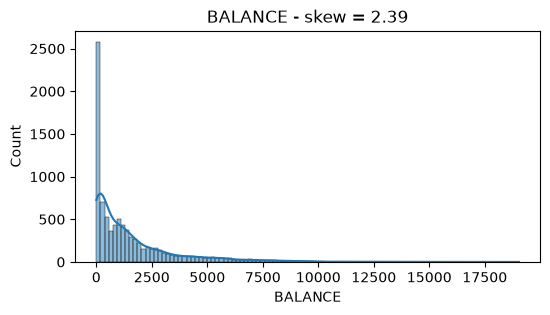

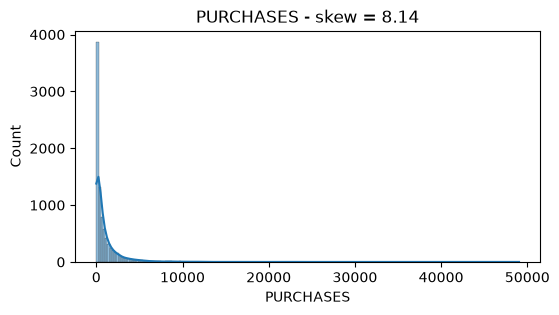

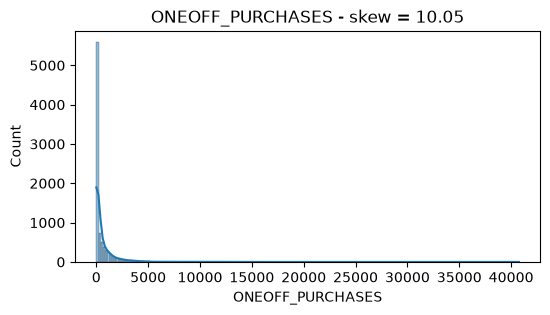

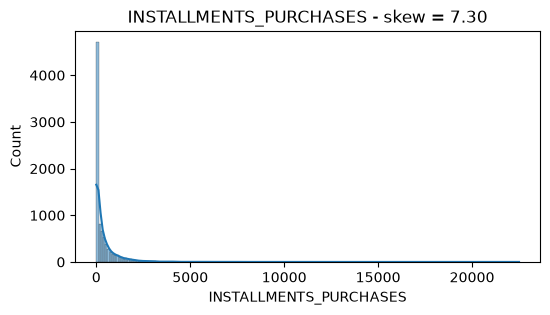

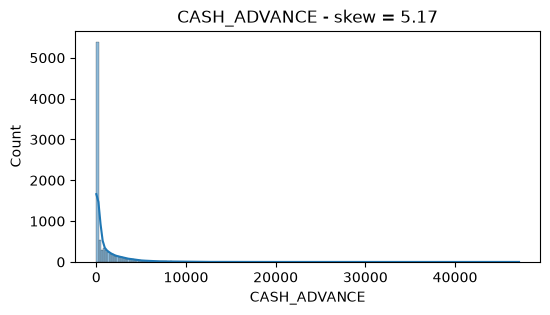

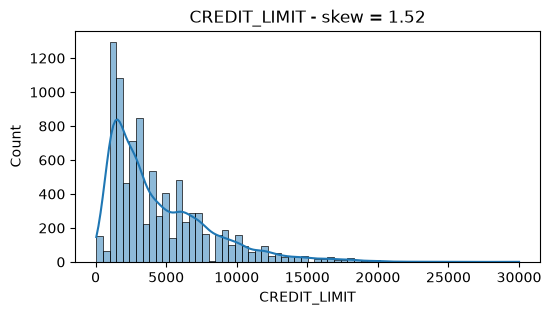

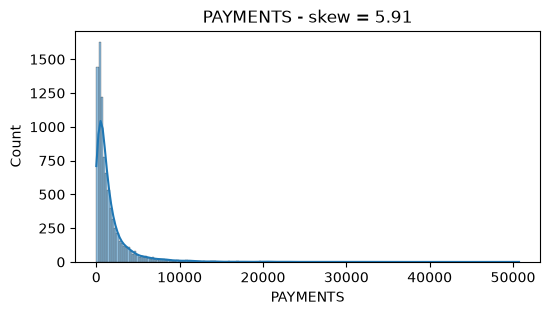

In [8]:
make_hists(df)

Correlation

In [9]:
get_corr(df).round(2)

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
BALANCE,1.00,0.18,0.16,0.13,0.50,0.53,0.32
PURCHASES,0.18,1.00,0.92,0.68,-0.05,0.36,0.60
ONEOFF_PURCHASES,0.16,0.92,1.00,0.33,-0.03,0.32,0.57
INSTALLMENTS_PURCHASES,0.13,0.68,0.33,1.00,-0.06,0.26,0.38
CASH_ADVANCE,0.50,-0.05,-0.03,-0.06,1.00,0.30,0.45
CREDIT_LIMIT,0.53,0.36,0.32,0.26,0.30,1.00,0.42
PAYMENTS,0.32,0.60,0.57,0.38,0.45,0.42,1.00


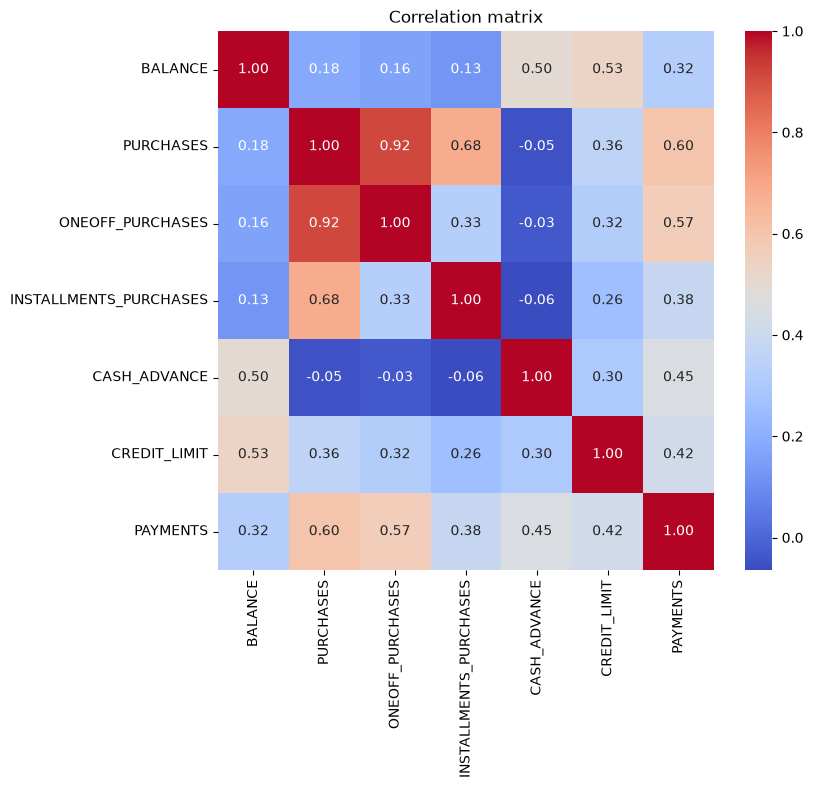

In [10]:
plot_corr_heatmap(df)

Outliers

In [11]:
outliers_summary(df)

,outliers,percent
column,,
CASH_ADVANCE,1030,11.51
ONEOFF_PURCHASES,1013,11.32
INSTALLMENTS_PURCHASES,867,9.69
PAYMENTS,808,9.03
PURCHASES,808,9.03
BALANCE,695,7.77
CREDIT_LIMIT,248,2.77


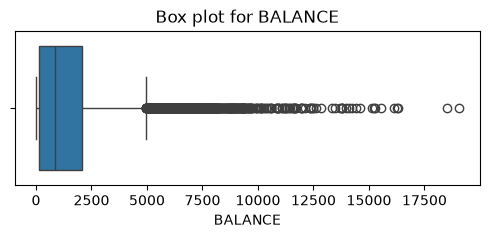

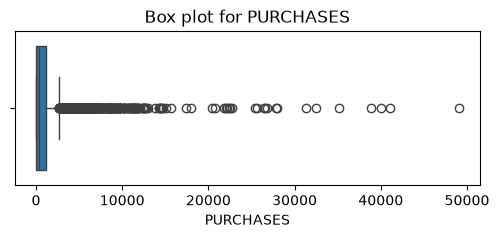

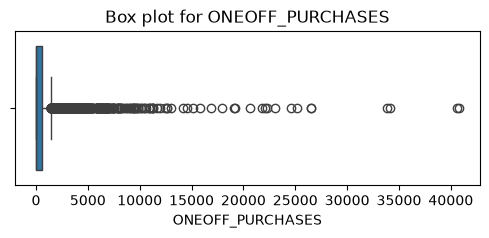

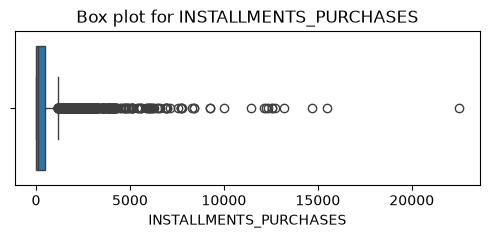

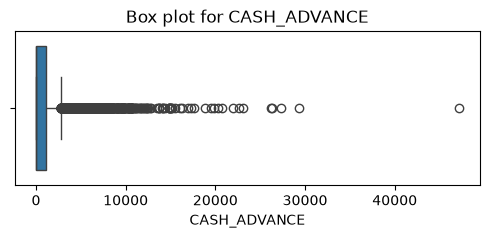

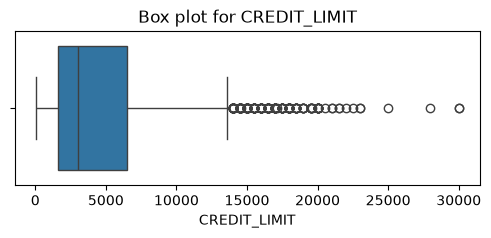

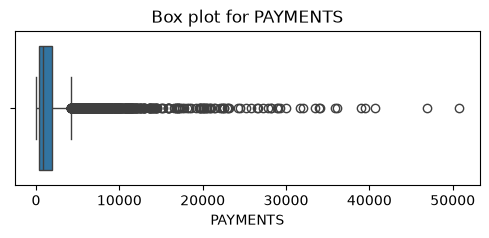

In [12]:
make_boxplots(df)

In [13]:
outliers, mask = get_outliers(df, "CASH_ADVANCE")
outliers.head()

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
1,C10002,3202.467416,0.00,0.00,0.00,6442.945483,7000.0,4103.032597
23,C10024,3800.151377,4248.35,3454.56,793.79,7974.415626,9000.0,9479.043842
30,C10031,12136.219960,3038.01,1013.20,2024.81,3183.583301,13000.0,4230.323491
36,C10037,7427.076941,0.00,0.00,0.00,8873.375046,9000.0,1636.361601
38,C10039,6269.418144,204.00,204.00,0.00,2925.699862,9000.0,1237.111661


Profiling report

In [14]:
# profile_report(df, "raw_data_profile.html", "Raw data profile")